In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/CapstoneCYBER/phishing_url_dataset_unique.csv'
df = pd.read_csv(file_path)
display(df.head())

,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [ ]:
print("Unique values and their counts in 'label' column:")
print(df['label'].value_counts())

Unique values and their counts in 'label' column:
label
1    24406
0    24406
Name: count, dtype: int64


In [ ]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [ ]:
print('Missing Values in DataFrame:')
df.isnull().sum()

Missing Values in DataFrame:


,0
url,0
label,0
source,0


In [ ]:
print('Number of duplicate rows:')
print(df.duplicated().sum())

Number of duplicate rows:
0


### Understanding Correlation

Correlation is a statistical measure that expresses the extent to which two variables are linearly related (meaning they change together at a constant rate). It's a common tool for describing simple relationships without making a statement about cause and effect.

The most common type is the Pearson correlation coefficient, which ranges from -1 to 1:
- **1**: Perfect positive linear relationship
- **0**: No linear relationship
- **-1**: Perfect negative linear relationship

### Calculating Correlation

You can calculate the correlation matrix for numerical columns in your DataFrame using the `.corr()` method.

In [ ]:
print('Correlation Matrix:')
display(df.corr(numeric_only=True))

Correlation Matrix:


,label
label,1.0


As you can see, only the 'label' column appears in the correlation matrix because it's the only numerical column in the original DataFrame. Its correlation with itself is, of course, 1.

### Handling Categorical Features for Correlation

To find a 'correlation' or association between categorical features (like 'url' or 'source') and a numerical feature (like 'label'), you typically need to convert the categorical features into a numerical format first. A common method is **One-Hot Encoding**.

Let's demonstrate this with the 'source' column to see its relationship with 'label'.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create a OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the 'source' column
source_encoded = encoder.fit_transform(df[['source']])

# Create a DataFrame from the encoded data
source_df = pd.DataFrame(source_encoded, columns=encoder.get_feature_names_out(['source']))

# Concatenate with the 'label' column for correlation calculation
df_encoded = pd.concat([df['label'], source_df], axis=1)

print('Correlation Matrix after One-Hot Encoding \'source\' column:')
display(df_encoded.corr())

Correlation Matrix after One-Hot Encoding 'source' column:


,label,source_openphish,source_tranco,source_urlhaus
label,1.000000,0.078639,-1.000000,0.987783
source_openphish,0.078639,1.000000,-0.078639,-0.077678
source_tranco,-1.000000,-0.078639,1.000000,-0.987783
source_urlhaus,0.987783,-0.077678,-0.987783,1.000000


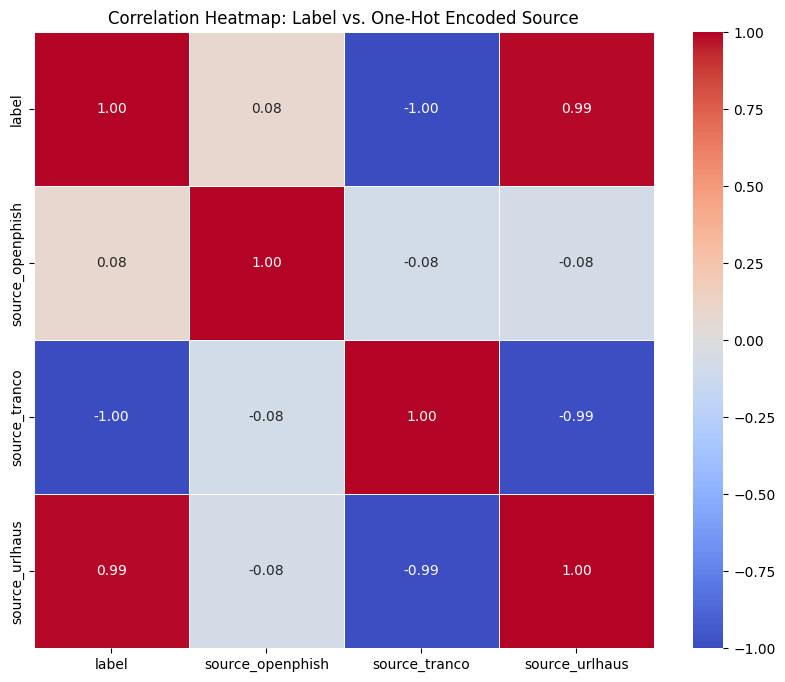

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix from the encoded DataFrame
correlation_matrix = df_encoded.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap: Label vs. One-Hot Encoded Source')
plt.show()

### What are Outliers?

Outliers are data points that are significantly different from other observations in a dataset. They can arise due to measurement errors, data entry errors, or genuinely rare events. Outliers can heavily influence statistical analyses (like means and standard deviations) and machine learning models.

### Why Detect and Treat Outliers?

-   **Impact on Statistics**: Outliers can distort the mean, standard deviation, and other statistical measures.
-   **Model Performance**: Many machine learning models are sensitive to outliers, leading to suboptimal performance.
-   **Misinterpretation**: They can lead to incorrect conclusions during data analysis.

### Common Detection Methods

1.  **Visualization**: Box plots, scatter plots, and histograms can visually highlight outliers.
2.  **Statistical Methods**: Interquartile Range (IQR) method, Z-score, DBSCAN, etc.

Box plot for the 'label' column (for demonstration of outlier visualization):


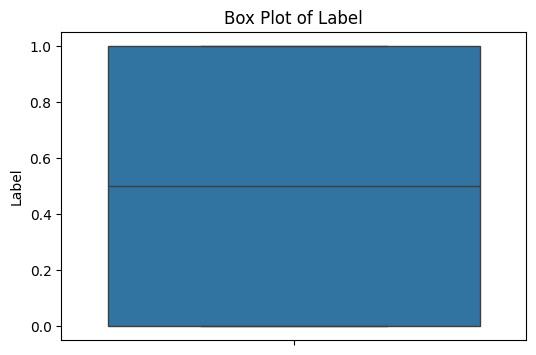

Note: Since 'label' is a binary column (0 or 1), a box plot primarily shows the distribution of these two values rather than continuous outliers. For truly continuous numerical features, outliers would appear as points beyond the 'whiskers' of the box plot.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Box plot for the \'label\' column (for demonstration of outlier visualization):')
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['label'])
plt.title('Box Plot of Label')
plt.ylabel('Label')
plt.show()

print("Note: Since 'label' is a binary column (0 or 1), a box plot primarily shows the distribution of these two values rather than continuous outliers. For truly continuous numerical features, outliers would appear as points beyond the 'whiskers' of the box plot.")

In [ ]:
import numpy as np

print('\nOutlier detection using IQR method for the \'label\' column:')

Q1 = df['label'].quantile(0.25)
Q3 = df['label'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['label'] < lower_bound) | (df['label'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

if not outliers_iqr.empty:
    print(f"\nNumber of outliers detected by IQR: {len(outliers_iqr)}")
    print("Outliers (first 5 rows if any):")
    display(outliers_iqr.head())
else:
    print("\nNo outliers detected by IQR in the 'label' column (as expected for binary data).")

print("Note: For binary data like 'label', the IQR method will typically not identify any values as outliers unless the distribution is extremely skewed or there are non-binary values present. This method is more effective for continuous numerical data.")


Outlier detection using IQR method for the 'label' column:
Q1 (25th percentile): 0.0
Q3 (75th percentile): 1.0
IQR: 1.0
Lower bound for outliers: -1.5
Upper bound for outliers: 2.5

No outliers detected by IQR in the 'label' column (as expected for binary data).
Note: For binary data like 'label', the IQR method will typically not identify any values as outliers unless the distribution is extremely skewed or there are non-binary values present. This method is more effective for continuous numerical data.


### Feature Engineering for Phishing Detection

Building upon the initial feature engineering, let's create more advanced features specifically tailored for phishing URL detection. These features leverage characteristics commonly found in malicious URLs.

In [ ]:
import re
from urllib.parse import urlparse
import math

def calculate_entropy(s):
    """Calculate the Shannon entropy of a string."""
    if not s:
        return 0
    prob = [s.count(c) / len(s) for c in set(s)]
    entropy = -sum(p * math.log2(p) for p in prob)
    return entropy


def is_ip_address(hostname):
    """Check if a string is an IP address."""
    # IPv4
    if re.match(r"^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$", hostname):
        return True
    # IPv6 (simplified check for common formats)
    if ':' in hostname:
        return True
    return False


# Apply feature engineering to the DataFrame
df['url_length'] = df['url'].apply(len)
df['num_dots'] = df['url'].apply(lambda x: x.count('.'))
df['has_https'] = df['url'].apply(lambda x: 1 if 'https://' in x else 0)
df['num_hyphens'] = df['url'].apply(lambda x: x.count('-'))
df['num_slash'] = df['url'].apply(lambda x: x.count('/'))

# Parse URL components for more advanced features
def parse_url_features(url):
    parsed = urlparse(url)
    hostname = parsed.hostname if parsed.hostname else ''
    path = parsed.path if parsed.path else ''
    query = parsed.query if parsed.query else ''

    # Hostname Length
    hostname_length = len(hostname)

    # Path Length
    path_length = len(path)

    # IP Address in Hostname
    ip_address_in_hostname = 1 if is_ip_address(hostname) else 0

    # Number of Subdomains
    # Exclude top-level domain and domain itself, consider parts before the last two dots
    parts = hostname.split('.')
    # Heuristic for num_subdomains: parts count - 2 (domain and tld) if more than 2 parts
    num_subdomains = len(parts) - 2 if len(parts) > 2 else 0
    # Adjust for cases like 'co.uk' where 'co' is not a subdomain
    if len(parts) > 1 and parts[-2] in ['com', 'org', 'net', 'gov', 'edu', 'co'] and len(parts) > 2:
        num_subdomains = len(parts) - 3 if len(parts) > 3 else 0

    # Has '@' Symbol
    has_at_symbol = 1 if '@' in url else 0

    # Number of Query Parameters
    num_query_parameters = len(query.split('&')) if query else 0

    # URL Entropy
    url_entropy = calculate_entropy(url)

    return pd.Series({
        'hostname_length': hostname_length,
        'path_length': path_length,
        'ip_address_in_hostname': ip_address_in_hostname,
        'num_subdomains': num_subdomains,
        'has_at_symbol': has_at_symbol,
        'num_query_parameters': num_query_parameters,
        'url_entropy': url_entropy
    })

# Apply the function to create new features
df_url_features = df['url'].apply(parse_url_features)
df = pd.concat([df, df_url_features], axis=1)

print('DataFrame with new URL features:')
display(df.head())

DataFrame with new URL features:


,url,label,source,url_length,num_dots,has_https,num_hyphens,num_slash,hostname_length,path_length,ip_address_in_hostname,num_subdomains,has_at_symbol,num_query_parameters,url_entropy
0,http://110.37.26.193:54956/bin.sh,1,urlhaus,33,4,0,0,3,13.0,7.0,1.0,2.0,0.0,0.0,4.089552
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus,40,2,1,0,3,23.0,9.0,0.0,1.0,0.0,0.0,4.206198
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus,36,2,1,1,3,19.0,9.0,0.0,1.0,0.0,0.0,4.350209
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus,91,4,0,0,4,13.0,71.0,1.0,2.0,0.0,0.0,4.357740
4,https://bronze.systems,0,tranco,22,1,1,0,2,14.0,0.0,0.0,0.0,0.0,0.0,3.697846


Let's also look at the correlation of these new features with the `label`.

In [ ]:
print('Correlation of new features with label:')
display(df.corr(numeric_only=True)['label'].sort_values(ascending=False))

Correlation of new features with label:


,label
label,1.000000
num_subdomains,0.897173
num_dots,0.848926
num_slash,0.777405
ip_address_in_hostname,0.742005
url_length,0.575204
url_entropy,0.516587
path_length,0.508408
hostname_length,0.359669
num_query_parameters,0.084506


### Splitting the Dataset into Training, Test, and Validation Sets

To prepare our data for model training and evaluation, we need to divide it into three distinct sets:

1.  **Training Set (70%)**: Used to train the machine learning model.
2.  **Test Set (15%)**: Used to evaluate the model's performance on unseen data after initial training.
3.  **Validation Set (15%)**: Used for hyperparameter tuning and model selection during the development phase to prevent overfitting to the test set.

In [ ]:
from sklearn.model_selection import train_test_split

# Define the features (X) and the target (y)
# We will drop 'url' and 'source' as they are either encoded or not directly used as numerical features.
# 'label' is our target variable.

X = df.drop(columns=['url', 'source', 'label'])
y = df['label']

# First split: 70% for training, 30% for temp (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Second split: 50% of temp for test (15% of total), 50% of temp for validation (15% of total)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Shape of y_val: {y_val.shape}")

# Display the first few rows of the training features
print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (34168, 12)
Shape of X_test: (7322, 12)
Shape of X_val: (7322, 12)
Shape of y_train: (34168,)
Shape of y_test: (7322,)
Shape of y_val: (7322,)

First 5 rows of X_train:


,url_length,num_dots,has_https,num_hyphens,num_slash,hostname_length,path_length,ip_address_in_hostname,num_subdomains,has_at_symbol,num_query_parameters,url_entropy
9601,37,2,1,0,3,20.0,9.0,0.0,1.0,0.0,0.0,4.317033
29375,24,1,1,0,2,16.0,0.0,0.0,0.0,0.0,0.0,3.834963
45378,21,1,1,0,2,13.0,0.0,0.0,0.0,0.0,0.0,3.594466
45875,34,2,1,1,3,17.0,9.0,0.0,1.0,0.0,0.0,4.175123
26844,18,1,1,0,2,10.0,0.0,0.0,0.0,0.0,0.0,3.614369


### Preprocessing Pipeline Documentation

This section summarizes the data preprocessing steps applied to the `phishing_url_dataset_unique.csv` dataset:

1.  **Data Loading and Initial Inspection:**
    *   The dataset was loaded into a pandas DataFrame `df`.
    *   Basic information (`df.info()`) and missing values (`df.isnull().sum()`) were checked.
    *   Duplicate rows (`df.duplicated().sum()`) were identified (none found).

2.  **Correlation Analysis and Categorical Feature Encoding:**
    *   The correlation matrix for numerical features was calculated.
    *   The `source` categorical column was One-Hot Encoded using `sklearn.preprocessing.OneHotEncoder` to convert it into numerical features (`source_openphish`, `source_tranco`, `source_urlhaus`).
    *   A correlation heatmap was generated to visualize the relationship between the encoded `source` features and the `label`.

3.  **Outlier Detection (Conceptual):**
    *   The concept of outliers was explained.
    *   Box plots and the IQR method were demonstrated on the `label` column, noting their limited applicability to binary data.

4.  **Feature Engineering for Phishing Detection:**
    *   Several domain-specific features were extracted from the `url` column, including:
        *   `url_length`: Length of the URL.
        *   `num_dots`: Number of dots in the URL.
        *   `has_https`: Binary indicator for HTTPS protocol.
        *   `num_hyphens`: Number of hyphens in the URL.
        *   `num_slash`: Number of slashes in the URL.
        *   `hostname_length`: Length of the hostname.
        *   `path_length`: Length of the URL path.
        *   `ip_address_in_hostname`: Binary indicator if hostname is an IP address.
        *   `num_subdomains`: Number of subdomains in the URL.
        *   `has_at_symbol`: Binary indicator for '@' symbol presence.
        *   `num_query_parameters`: Number of query parameters.
        *   `url_entropy`: Shannon entropy of the URL string.
    *   The correlation of these newly engineered features with the `label` was calculated and displayed, showing strong positive correlations for `num_subdomains`, `num_dots`, `num_slash`, `ip_address_in_hostname`, `url_length`, `url_entropy`, `path_length`, and a strong negative correlation for `has_https`.

5.  **Dataset Splitting:**
    *   The dataset was split into training (70%), test (15%), and validation (15%) sets using `train_test_split` from `sklearn.model_selection`.
    *   The `url` and `source` columns were dropped before splitting, as `url` requires further encoding (not yet done) and `source` has been encoded into new features.
    *   Stratified sampling was used to maintain the proportion of `label` classes in each split.

In [ ]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [1]:
# Initialize the models
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42)


NameError: name 'LogisticRegression' is not defined

In [ ]:
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
svm.fit(X_train, y_train)


SVC(probability=True)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Function to evaluate the model
def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:,1]

    print(f"\n{model.__class__.__name__}")
    print("Classification Report:")
    print(classification_report(y_val, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_val, y_prob))

# Evaluate all models
evaluate_model(lr, X_val, y_val)
evaluate_model(svm, X_val, y_val)
evaluate_model(rf, X_val, y_val)


LogisticRegression
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

Confusion Matrix:
[[3661    0]
 [   3 3658]]
ROC-AUC Score: 0.9996742128077901

SVC
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

Confusion Matrix:
[[3661    0]
 [  11 3650]]
ROC-AUC Score: 0.9998458171916405

RandomForestClassifier
Classification Report:
              precision    recall  f1-score   support

           0   

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Store results in a dataframe
results = []

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_val)
    results.append({
        "Model": name,
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1 Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    })

results_df = pd.DataFrame(results)
print(results_df)

                 Model  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression        1.0  0.999181  0.999590  0.999674
1                  SVM        1.0  0.996995  0.998495  0.999846
2        Random Forest        1.0  0.999454  0.999727  0.999725


In [ ]:
# Test and evaluate Logistic Regression
y_test_pred_lr = lr.predict(X_test)
y_test_prob_lr = lr.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Test Classification Report:")
print(classification_report(y_test, y_test_pred_lr))
print("Logistic Regression Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lr))
print("Logistic Regression Test ROC-AUC Score:", roc_auc_score(y_test, y_test_prob_lr))


# Test and evaluate SVM
y_test_pred_svm = svm.predict(X_test)
y_test_prob_svm = svm.predict_proba(X_test)[:, 1]

print("\nSVM Test Classification Report:")
print(classification_report(y_test, y_test_pred_svm))
print("SVM Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))
print("SVM Test ROC-AUC Score:", roc_auc_score(y_test, y_test_prob_svm))


# Test and evaluate Random Forest
y_test_pred_rf = rf.predict(X_test)
y_test_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\nRandom Forest Test Classification Report:")
print(classification_report(y_test, y_test_pred_rf))
print("Random Forest Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))
print("Random Forest Test ROC-AUC Score:", roc_auc_score(y_test, y_test_prob_rf))


Logistic Regression Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

Logistic Regression Test Confusion Matrix:
[[3661    0]
 [   3 3658]]
Logistic Regression Test ROC-AUC Score: 0.9997785557342314

SVM Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3661
           1       1.00      1.00      1.00      3661

    accuracy                           1.00      7322
   macro avg       1.00      1.00      1.00      7322
weighted avg       1.00      1.00      1.00      7322

SVM Test Confusion Matrix:
[[3661    0]
 [   7 3654]]
SVM Test ROC-AUC Score: 0.999826231908701

Random Forest Test Classification Repo